In [1]:
import json
import struct
import numpy as np
import matplotlib.pyplot as plt
import photonforge as pf
import siepic_forge as siepic
import luxtelligence_lnoi400_forge as lxt
import tidy3d as td

td.config.logging_level = "ERROR"

# Set up technologies
siepic_tech = siepic.ebeam()
basic_tech = pf.basic_technology()
lxt_tech = lxt.lnoi400()
pf.config.default_technology = siepic_tech

# Initialize live viewer for real-time visualization
from photonforge.live_viewer import LiveViewer
viewer = LiveViewer()

# Define simulation parameters
wavelengths = np.linspace(1.53, 1.57, 101)
freqs = pf.C_0 / wavelengths

LiveViewer started at http://localhost:52808


In [2]:
dual_mode_spec = siepic_tech.ports["TE_1550_500"].copy()
dual_mode_spec.num_modes = 2  # Use both modes

siepic_tech.add_port("TE-TM_1550_500", dual_mode_spec)
siepic_tech.ports["TE-TM_1550_500"]

PortSpec(description="Strip TE 1550 nm, w=500 nm", width=2, limits=(-1, 1.22), num_modes=2, added_solver_modes=0, polarization="", target_neff=3.5, default_radius=0, path_profiles=[(0.5, 0, (1, 0))])

In [3]:
@pf.parametric_component
def mmi_2x2(
    *,
    length=32.25,
    width=3.5,
    taper_length=7.5,
    taper_gap=0.4,
    tapered_width=1.6,
    port_spec="TE_1550_500"
):
    """
    Creates a parametric 2x2 multimode interference (MMI) splitter component.

    Parameters:
        length (float): Length of the central MMI region (μm).
        width (float): Width of the central MMI region (μm).
        taper_length (float): Length of input/output waveguide ports (μm).
        tapered_width (float): Width at the tapered junction between ports and MMI region (μm).
        port_spec (photonforge.PortSpec): Port specifications for this component

    Returns:
        PhotonForge Component: Configured MMI splitter with ports and simulation model.
    """
    if isinstance(port_spec, str):
        port_spec = pf.config.default_technology.ports[port_spec]

    # Create an empty component named "MMI2x2"
    mmi = pf.Component("MMI_2x2")

    port_width, _ = port_spec.path_profile_for("Si")

    mmi_center = pf.Rectangle(size=(length, width))

    p0_taper = pf.stencil.linear_taper(taper_length, (port_width, tapered_width))
    p1_taper = pf.stencil.linear_taper(taper_length, (port_width, tapered_width))
    p2_taper = pf.stencil.linear_taper(taper_length, (port_width, tapered_width))
    p3_taper = pf.stencil.linear_taper(taper_length, (port_width, tapered_width))

    p0_taper.x_max = -length / 2
    p0_taper.y_mid = -(taper_gap / 2 + tapered_width / 2)
    p1_taper.x_max = -length / 2
    p1_taper.y_mid = taper_gap / 2 + tapered_width / 2

    p2_taper.rotate(180)
    p3_taper.rotate(180)
    p2_taper.x_min = length / 2
    p2_taper.y_mid = -(taper_gap / 2 + tapered_width / 2)
    p3_taper.x_min = length / 2
    p3_taper.y_mid = taper_gap / 2 + tapered_width / 2

    mmi.add("Si", mmi_center, p0_taper, p1_taper, p2_taper, p3_taper)

    # Detect and add ports automatically
    mmi.add_port(mmi.detect_ports([port_spec]))
    assert len(mmi.ports) == 4, "Port detection failed: expected exactly 4 ports."

    port_symmetries = [
        ("P1", "P0", "P3", "P2"),
        ("P2", "P3", "P0", "P1"),
        ("P3", "P2", "P1", "P0"),
    ]

    field_monitor = td.FieldMonitor(
        center=(0, 0, 0.11), size=(td.inf, td.inf, 0), freqs=[freqs.mean()], name="field"
    )

    # Include the Tidy3D simulation model
    mmi.add_model(pf.Tidy3DModel(port_symmetries=port_symmetries, monitors=[field_monitor]), "Tidy3DModel")

    return mmi


# Instantiate the component with custom dimensions
mmi = mmi_2x2()
# viewer.display(mmi)

In [4]:
@pf.parametric_component
def mmi_swg_2x2(
    *,
    length=32.25,
    width=3.5,
    taper_length=7.5,
    taper_gap=0.4,
    tapered_width=1.6,
    swg_period_x = 0.25,
    swg_period_y = 0.20,
    swg_cell_width = 0.1,
    port_spec="TE_1550_500"
):
    """
    Creates a parametric 2x2 multimode interference (MMI) splitter component.

    Parameters:
        length (float): Length of the central MMI region (μm).
        width (float): Width of the central MMI region (μm).
        taper_length (float): Length of input/output waveguide ports (μm).
        tapered_width (float): Width at the tapered junction between ports and MMI region (μm).
        port_spec (photonforge.PortSpec): Port specifications for this component

    Returns:
        PhotonForge Component: Configured MMI splitter with ports and simulation model.
    """
    if isinstance(port_spec, str):
        port_spec = pf.config.default_technology.ports[port_spec]

    port_width, _ = port_spec.path_profile_for("Si")

    # Create an empty component named "MMI2x2"
    mmi_swg = pf.Component("MMI_SWG_2x2")

    mmi = mmi_2x2(length=length, width=width, taper_length=taper_length, taper_gap=taper_gap, tapered_width=tapered_width, port_spec=port_spec)

    swg_cell = pf.Component("SWG_Cell")
    hole = pf.Rectangle(size=(swg_cell_width, swg_cell_width))
    swg_cell.add("Si", hole)

    taper_overlap = 2*(taper_length/3)

    swg_center_holes = pf.Reference(
        component=swg_cell, columns=int((length+taper_overlap)/swg_period_x)+1, rows=int(width/swg_period_y)+1, spacing=(swg_period_x, swg_period_y)
    ).translate((-(length+taper_overlap)/2, -(width-swg_cell_width)/2))

    mmi_cut = pf.boolean(mmi, swg_center_holes, operation="-")

    swg_taper_cell = pf.Component("SWG_Taper_Cell")
    strip = pf.Rectangle(size=(swg_cell_width, width))
    swg_taper_cell.add("Si", strip)

    swg_taper_strips = pf.Reference(
        component=swg_taper_cell, columns=int((taper_length-taper_overlap/2)/swg_period_x)+1, rows=1, spacing=(swg_period_x, 0)
    ).translate((-(length/2 + taper_length), 0))

    mmi_cut = pf.boolean(mmi_cut, swg_taper_strips, operation="-")

    swg_taper_strips = pf.Reference(
        component=swg_taper_cell, columns=int((taper_length-taper_overlap/2)/swg_period_x)+1, rows=1, spacing=(swg_period_x, 0)
    ).translate(((length/2 + taper_overlap/2), 0))

    mmi_cut = pf.boolean(mmi_cut, swg_taper_strips, operation="-")

    

    for region in mmi_cut:
        mmi_swg.add("Si", region)

    # Detect and add ports automatically
    mmi_swg.add_port(mmi_swg.detect_ports([port_spec]))
    # assert len(mmi_swg.ports) == 4, "Port detection failed: expected exactly 4 ports."

    port_symmetries = [
        ("P1", "P0", "P3", "P2"),
        ("P2", "P3", "P0", "P1"),
        ("P3", "P2", "P1", "P0"),
    ]

    field_monitor = td.FieldMonitor(
        center=(0, 0, 0.11), size=(td.inf, td.inf, 0), freqs=[freqs.mean()], name="field"
    )

    # Include the Tidy3D simulation model
    mmi_swg.add_model(pf.Tidy3DModel(port_symmetries=port_symmetries, monitors=[field_monitor]), "Tidy3DModel")

    return mmi_swg


# Instantiate the component with custom dimensions
mmi_swg = mmi_swg_2x2()
viewer.display(mmi_swg)

In [5]:
# Define a parametric 2x2 MMI splitter component
@pf.parametric_component
def mmi_2x2(
    *,
    l1=4.41,  # length of taper section at input
    l2=4.51,  # length of intermediate taper section
    l3=3.01,  # length of central multimode section
    w1=2.05,  # intermediate width near input/output
    w2=2.05,  # central section width
    w5=0.972,  # input taper narrow width
    w6=0.284,  # gap between input waveguides
    port_spec="TE_1550_500"  # port specification for waveguides
):
    """
    Creates a parametric 2x2 multimode interference (MMI) splitter component.

    Parameters:
        l1, l2, l3 (float): Section lengths.
        w1, w2, w5, w6 (float): Section widths.
        port_spec: Specification for the optical ports.

    Returns:
        PhotonForge Component: Configured MMI with geometry and simulation model.
    """
    # Resolve port specification if provided as string
    if isinstance(port_spec, str):
        port_spec = pf.config.default_technology.ports[port_spec]

    # Initialize an empty component named "MMI2x2"
    mmi = pf.Component("MMI2x2")

    # Extract default waveguide width from port specification
    wg_width, _ = port_spec.path_profile_for("Si")

    # Calculate widths based on given parameters
    w3 = 2 * w5 + w6
    w4 = wg_width

    # Define paths for input and output waveguides
    input_wg_up = pf.Path((0, (w5 + w6) / 2), w4).segment((l1, 0), w5, relative=True)
    input_wg_down = input_wg_up.copy().mirror()
    output_wg_up = input_wg_up.copy().mirror(
        axis_endpoint=(l1 + l2 + l3, 1), axis_origin=(l1 + l2 + l3, 0)
    )
    output_wg_down = output_wg_up.copy().mirror()

    # Define the central multimode section of MMI
    central_section = (
        pf.Path((l1, 0), w3)
        .segment((l2, 0), w1, relative=True)
        .segment((l3, 0), w2, relative=True)
        .segment((l3, 0), w2, relative=True)
        .segment((l2, 0), w3, relative=True)
    )

    # Add the defined geometries to the silicon ("Si") layer
    mmi.add(
        "Si", input_wg_up, input_wg_down, output_wg_up, output_wg_down, central_section
    )

    # Automatically detect and add ports
    mmi.add_port(mmi.detect_ports([port_spec]))
    
    assert len(mmi.ports) == 4, "Port detection failed: expected exactly 4 ports."

    # Include the Tidy3D simulation model with specified port symmetries
    mmi.add_model(
        pf.Tidy3DModel(
            port_symmetries=[
                ("P1", "P0", "P3", "P2"),  # reflection symmetry about x axis
                ("P2", "P3", "P0", "P1"),  # reflection symmetry about y axis
                ("P3", "P2", "P1", "P0"),  # inversion symmetry about the origin
            ],
        ),
        "Tidy3DModel",
    )

    return mmi

# Instantiate the MMI component with default dimensions
mmi = mmi_2x2(port_spec="TE_1550_500")
viewer(mmi)

c:\Users\irfan\AppData\Local\Programs\Python\Python313\Lib\site-packages\photonforge\parametric_utils.py:208: RuntimeWarning: Component function '__main__.mmi_2x2' previously registered will be overwritten.
  return _decorator(decorated_function)


In [102]:
simulations = mmi.active_model.get_simulations(mmi, freqs)

# simulations.keys()
td.web.Batch(simulations=simulations).estimate_cost()

23:56:32 SE Asia Standard Time Maximum FlexCredit cost: 4.421 for the whole     
                               batch.

4.420956178844662

In [37]:
@pf.parametric_component
def test_circuit(straight_length=50):
    component = pf.Component("test")

    straight = pf.parametric.straight(port_spec="TE_1550_500", length=straight_length)
    mmi = mmi_2x2(port_spec="TE_1550_500")

    str1_ref = component.add_reference(straight)
    # str2_ref = component.add_reference(straight)
    mmi_ref = component.add_reference(mmi)

    mmi_ref.connect("P0", str1_ref["P1"])
    # str2_ref.connect("P0", mmi_ref["P1"])

    component.add_port(component.detect_ports(["TE_1550_500"]))
    component.add_model(pf.CircuitModel(), "CircuitModel")

    return component
component = test_circuit(straight_length=10)
viewer(component)

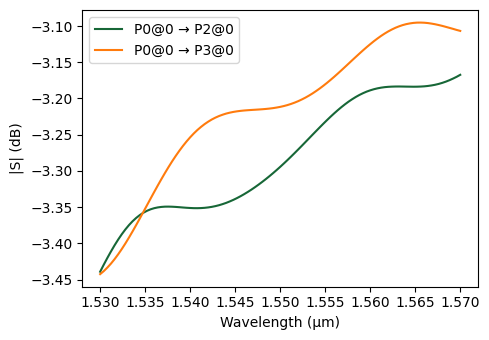

In [39]:
mmi = test_circuit(straight_length=1)

s_matrix = mmi.s_matrix(freqs, model_kwargs={"inputs": ["P0"]})
fig, ax = pf.plot_s_matrix(s_matrix, y="dB", input_ports=["P0"], output_ports=["P2", "P3"])

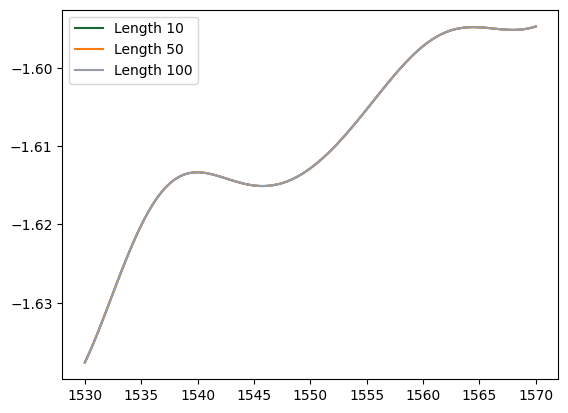

In [38]:
fig, ax = plt.subplots()

for length in [10, 50, 100]:
    s_matrix = test_circuit(straight_length=length).s_matrix(freqs, model_kwargs={"inputs": ["P0"]})
    phase0 = np.unwrap(np.angle(s_matrix[("P0@0", "P2@0")]))
    phase1 = np.unwrap(np.angle(s_matrix[("P0@0", "P3@0")]))
    delta = phase1 - phase0
    ax.plot(
        wavelengths * 1e3,
        delta,
        linewidth=1.5,
        label=f"Length {length}",
    )
    ax.legend()

In [11]:
sim_data = mmi.active_model.batch_data_for(mmi)
_ = sim_data["P0@0"].plot_field("field", "E", val="abs^2", robust=False)

AttributeError: 'CircuitModel' object has no attribute 'batch_data_for'